In [4]:
import sys
import os
from dotenv import load_dotenv
import guidance
from guidance import system, user, assistant, gen
import math
import itertools

from typing import Dict, List, Tuple
import itertools
from typing import Dict, List, Tuple
import itertools

# Setup local pywhyllm development environment in one line
from notebook_setup import setup_local_pywhyllm
project_root = setup_local_pywhyllm()

# Now import the SimpleModelSuggester
#TFM/pywhyllm/pywhyllm/suggesters --> crear variable 

# project_root = os.path.abspath("/home/moleropa/repositories/master/TFM/pywhyllm/pywhyllm/suggesters/")  # Navigate to TFM/pywhyllm/
# sys.path.insert(0, project_root)


from openai import OpenAI
from portkey_ai import createHeaders
from dotenv import load_dotenv
import time
import base64
from IPython.display import display, Image
from pydantic import BaseModel
import json
load_dotenv()

 Local pywhyllm source already in Python path


True

Example using logprobs

In [2]:
azure_model= "gpt-4o-mini" #"GPT-4o-2024-05-13" 
us_base_url = "https://us.aigw.galileo.roche.com/v1"
portkey_headers = createHeaders(config=os.environ["PORTKEY_AZURE_US_CONFIG"])

azure_openai_client = OpenAI(base_url=us_base_url,
            api_key=os.environ["PORTKEY_AZURE_US_API_KEY"],
            default_headers=portkey_headers)
# start = time.time()
# response = azure_openai_client.chat.completions.create(
#     messages=[
#         {
#             "role": "user",
#             "content": "What is Generative AI in one sentence?",
#         }
#     ],
#     model=azure_model,
#     temperature=0.1,
#     logprobs=True,
#     top_logprobs=1,
# )
# print(f"Response time: {time.time() - start}s")
# print(f"Response: {response.choices[0].message.content}")
# print(f"Tokens: {response.usage.total_tokens}")
# print()

In [3]:
azure_model= "gpt-4o-mini" #"GPT-4o-2024-05-13" 
us_base_url = "https://us.aigw.galileo.roche.com/v1"

portkey_headers = createHeaders(config=os.environ["PORTKEY_AZURE_US_CONFIG"])
# azure_openai_client = OpenAI(base_url=us_base_url,
#             api_key=os.environ["PORTKEY_AZURE_US_API_KEY"],
#             default_headers=portkey_headers)


# Guidance con modelo OpenAI + base_url + headers
model = guidance.models.OpenAI(
    #"GPT-4o-2024-05-13",
    azure_model,
    api_key=os.environ["PORTKEY_AZURE_US_API_KEY"],
    base_url=us_base_url,
    default_headers=portkey_headers,
)


In [4]:
# Import hallbayes repository for hallucination risk assessment
hallbayes_path = os.path.abspath("../../hallbayes")
sys.path.insert(0, hallbayes_path)

from scripts.hallucination_toolkit import OpenAIBackend, OpenAIItem, OpenAIPlanner

Structure: Guidance uses context managers (with guidance.user() and with guidance.assistant()) to structure the conversation
Model State: The lm object accumulates the conversation state as you add to it with +=
Generation: Use guidance.gen() instead of the OpenAI completion parameters
Response Access: Access the generated response via lm['response'] using the name specified in gen()
The guidance approach is more declarative and gives you fine-grained control over the conversation flow, making it particularly useful for complex prompting patterns and multi-step reasoning tasks.

In [5]:
from dotenv import load_dotenv
import guidance
from openai import OpenAI
from portkey_ai import createHeaders

load_dotenv()

# Initialize LLM (using your Azure/OpenAI setup)
azure_model = "gpt-4o-mini"
us_base_url = "https://us.aigw.galileo.roche.com/v1"

portkey_headers = createHeaders(config=os.environ["PORTKEY_AZURE_US_CONFIG"])

# For guidance (used by SimpleModelSuggester methods)
model = guidance.models.OpenAI(
    azure_model,
    api_key=os.environ["PORTKEY_AZURE_US_API_KEY"],
    base_url=us_base_url,
    default_headers=portkey_headers
)

# For LangChain (used by query_llm in RAG)
from langchain_openai import ChatOpenAI

langchain_llm = ChatOpenAI(
    model=azure_model,
    api_key=os.environ["PORTKEY_AZURE_US_API_KEY"],
    base_url=us_base_url,
    default_headers=portkey_headers,
    temperature=0
)

print("✓ Guidance LLM initialized")
print("✓ LangChain LLM initialized")

✓ Guidance LLM initialized
✓ LangChain LLM initialized


In [6]:
from pywhyllm.suggesters.augmented_model_suggester_alba import AugmentedModelSuggester


# Use existing CauseNet file (avoids SSL download errors)
#causenet_path = "data/causenet-precision.jsonl.bz2"
causenet_path ="/home/moleropa/repositories/master/TFM/pywhyllm/docs/notebooks/tuebingen_causality_pairs/data/causenet-precision.jsonl.bz2"
# Initialize with both Guidance and LangChain LLMs
suggester = AugmentedModelSuggester(
    llm=model,  # Guidance model for simple suggester methods
    langchain_llm=langchain_llm,  # LangChain model for RAG queries
    pubmed_email="albamaria.molero.perez@example.com",  # Replace with your email
    file_path=causenet_path  # Use existing local file
)

print("✓ AugmentedModelSuggester initialized")
print(f"  CauseNet entries loaded: {len(suggester.causenet_dict)}")

✓ CauseNet found locally at /home/moleropa/repositories/master/TFM/pywhyllm/docs/notebooks/tuebingen_causality_pairs/data/causenet-precision.jsonl.bz2
Loading CauseNet using json
Done loading CauseNet using json
Creating dictionary from CauseNet json data
Done creating dictionary from CauseNet json data
✓ AugmentedModelSuggester initialized
  CauseNet entries loaded: 197806


In [ ]:

def suggest_relationships_rag(self, variables: List[str],
        use_pubmed=True,
        max_pubmed_papers=5,
        return_prompt=True, 
        confidence_level=False):
    """
    Given a list of variables, suggests relationships between them by querying for pairwise relationships.

    Args:
        variables (List[str]): A list of variable names.

    Returns:
        dict: A dictionary of edges found between variables, where the keys are tuples representing 
        the causal relationship between two variables, and the values are the description.
    """
    relationships = {}
    total = int(len(variables) * (len(variables) - 1) / 2)
    i = 0
    
    print(f"🔍 Starting pairwise causal relationship discovery")
    print(f"📊 Total pairs to evaluate: {total}")
    print(f"⚙️  Settings: PubMed={use_pubmed}, Max papers={max_pubmed_papers}")
    print("=" * 70)
    
    for (var1, var2) in itertools.combinations(variables, 2):
        i += 1
        print(f"\n[{i}/{total}] Querying: {var1} ↔ {var2}")
        
        try:
            # Call the method - returns dict when return_prompt=True
            result_data = self.suggest_pairwise_relationship(
                variable1=var1, 
                variable2=var2, 
                use_pubmed=use_pubmed,
                max_pubmed_papers=max_pubmed_papers,
                return_prompt=return_prompt, 
                confidence_level=confidence_level
            )
            
            # Handle different return types based on parameters
            if return_prompt:
                # Returns dict with 'result', 'system_prompt', etc.
                if isinstance(result_data, dict):
                    result_list = result_data['result']
                    cause, effect, description = result_list[0], result_list[1], result_list[2]
                    
                    if cause is not None and effect is not None:
                        relationships[(cause, effect)] = description
                        print(f"  ✅ Found: {cause} → {effect}")
                        
                        # Optionally print confidence if available
                        if 'confidence_score' in result_data and result_data['confidence_score']:
                            print(f"     Confidence: {result_data['confidence_score']:.3f}")
                    else:
                        print(f"  ❌ No relationship found")
                else:
                    print(f"  ⚠️  Unexpected return type: {type(result_data)}")
            else:
                # Without return_prompt, returns tuple or list directly
                if confidence_level:
                    # Returns (result_list, confidence_score)
                    result_list, confidence_score = result_data
                else:
                    # Returns just result_list
                    result_list = result_data
                
                cause, effect, description = result_list[0], result_list[1], result_list[2]
                
                if cause is not None and effect is not None:
                    relationships[(cause, effect)] = description
                    print(f"  ✅ Found: {cause} → {effect}")
                else:
                    print(f"  ❌ No relationship found")
                
        except Exception as e:
            print(f"  ⚠️  ERROR: {str(e)[:200]}")
            import traceback
            traceback.print_exc()
    
    print("\n" + "=" * 70)
    print(f"✅ Discovery complete! Found {len(relationships)} causal relationships")
    print("=" * 70)
    
    return relationships

In [9]:
def suggest_relationships_rag(self, variables: List[str],
        use_pubmed=True,
        max_pubmed_papers=5,
        return_prompt=True, 
        confidence_level=False):
    """
    Given a list of variables, suggests relationships between them by querying for pairwise relationships.

    Args:
        variables (List[str]): A list of variable names.

    Returns:
        dict: A dictionary of edges found between variables, where the keys are tuples representing 
        the causal relationship between two variables, and the values include the description,
        CauseNet text, and PubMed text.
    """
    relationships = {}
    total = int(len(variables) * (len(variables) - 1) / 2)
    i = 0
    
    print(f"🔍 Starting pairwise causal relationship discovery")
    print(f"📊 Total pairs to evaluate: {total}")
    print(f"⚙️  Settings: PubMed={use_pubmed}, Max papers={max_pubmed_papers}")
    print("=" * 70)
    
    for (var1, var2) in itertools.combinations(variables, 2):
        i += 1
        print(f"\n[{i}/{total}] Querying: {var1} ↔ {var2}")
        
        try:
            # Call the method - returns dict when return_prompt=True
            result_data = self.suggest_pairwise_relationship(
                variable1=var1, 
                variable2=var2, 
                use_pubmed=use_pubmed,
                max_pubmed_papers=max_pubmed_papers,
                return_prompt=return_prompt, 
                confidence_level=confidence_level
            )
            
            # Handle different return types based on parameters
            if return_prompt:
                # Returns dict with 'result', 'system_prompt', 'causenet_text', 'pubmed_text'
                if isinstance(result_data, dict):
                    result_list = result_data['result']
                    cause, effect, description = result_list[0], result_list[1], result_list[2]
                    
                    if cause is not None and effect is not None:
                        # Store comprehensive information with CORRECT key names
                        relationships[(cause, effect)] = {
                            'description': description,
                            'causenet_text': result_data.get('causenet_text', 'Not available'),
                            'pubmed_text': result_data.get('pubmed_text', 'Not available'),
                            'system_prompt': result_data.get('system_prompt', ''),
                            'user_prompt': result_data.get('user_prompt', '')
                        }
                        
                        print(f"  ✅ Found: {cause} → {effect}")
                        
                        # Print evidence summary
                        if result_data.get('causenet_text'):
                            print(f"     📚 CauseNet: {len(result_data.get('causenet_text', ''))} chars")
                        if result_data.get('pubmed_text'):
                            print(f"     📄 PubMed: {len(result_data.get('pubmed_text', ''))} chars")
                        
                        # Optionally print confidence if available
                        if 'confidence_score' in result_data and result_data['confidence_score']:
                            print(f"     🎯 Confidence: {result_data['confidence_score']:.3f}")
                    else:
                        print(f"  ❌ No relationship found")
                else:
                    print(f"  ⚠️  Unexpected return type: {type(result_data)}")
            else:
                # Without return_prompt, returns tuple or list directly
                if confidence_level:
                    # Returns (result_list, confidence_score)
                    result_list, confidence_score = result_data
                else:
                    # Returns just result_list
                    result_list = result_data
                
                cause, effect, description = result_list[0], result_list[1], result_list[2]
                
                if cause is not None and effect is not None:
                    relationships[(cause, effect)] = {'description': description}
                    print(f"  ✅ Found: {cause} → {effect}")
                else:
                    print(f"  ❌ No relationship found")
                
        except Exception as e:
            print(f"  ⚠️  ERROR: {str(e)[:200]}")
            import traceback
            traceback.print_exc()
    
    print("\n" + "=" * 70)
    print(f"✅ Discovery complete! Found {len(relationships)} causal relationships")
    print("=" * 70)
    
    return relationships

In [10]:
from types import MethodType

suggester.suggest_relationships_rag = MethodType(
    suggest_relationships_rag, suggester
)

In [13]:
# Simple timeout handling approach
start_time = time.time()

#variables = ["obesity", "hypertension", "age"] #, "cardiac ischemia", "diabetes mellitus", "major acute cardiovascular event"]
variables = ["obesity", "hypertension", "age", "cardiac ischemia", "diabetes mellitus", "major acute cardiovascular event"]

results = suggester.suggest_relationships_rag(
        variables=variables,
        use_pubmed=True,
        max_pubmed_papers=5,
        return_prompt=True, 
        confidence_level=False
)

elapsed_time = time.time() - start_time

🔍 Starting pairwise causal relationship discovery
📊 Total pairs to evaluate: 15
⚙️  Settings: PubMed=True, Max papers=5

[1/15] Querying: obesity ↔ hypertension

🔬 Analyzing: obesity ↔ hypertension

📖 Step 1: Searching CauseNet...


INFO:sentence_transformers.SentenceTransformer:Use pytorch device_name: cpu
INFO:sentence_transformers.SentenceTransformer:Load pretrained SentenceTransformer: all-MiniLM-L6-v2


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

...

✗ No CauseNet match above threshold 0.35 (Best: 0.2648 for 'gata2_deficiency-endocarditis')
   ✗ No CauseNet match found

📚 Step 2: Searching PubMed...
🔍 Searching PubMed for: diabetes mellitus ↔ major acute cardiovascular event
   Trying query: diabetes mellitus AND major acute cardiovascular event AND (causal OR causation OR cause)


INFO:sentence_transformers.SentenceTransformer:Use pytorch device_name: cpu
INFO:sentence_transformers.SentenceTransformer:Load pretrained SentenceTransformer: sentence-transformers/all-MiniLM-L6-v2


   ✓ Found 5 papers
📚 Total papers retrieved: 5
   ✓ Retrieved PubMed literature (text length: 8375 chars)

🤖 Step 3: Querying LLM...
📊 Creating combined retriever (text length: 8414 chars)


INFO:backoff:Backing off send_request(...) for 0.3s (requests.exceptions.SSLError: HTTPSConnectionPool(host='us.i.posthog.com', port=443): Max retries exceeded with url: /batch/ (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: self-signed certificate in certificate chain (_ssl.c:1016)'))))
INFO:backoff:Backing off send_request(...) for 0.2s (requests.exceptions.SSLError: HTTPSConnectionPool(host='us.i.posthog.com', port=443): Max retries exceeded with url: /batch/ (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: self-signed certificate in certificate chain (_ssl.c:1016)'))))
INFO:backoff:Backing off send_request(...) for 1.8s (requests.exceptions.SSLError: HTTPSConnectionPool(host='us.i.posthog.com', port=443): Max retries exceeded with url: /batch/ (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: self-signed

   ✓ LLM response generated with RAG augmentation

📋 Step 4: Parsing result...
   → Causal direction: diabetes mellitus → major acute cardiovascular event

  ✅ Found: diabetes mellitus → major acute cardiovascular event
     📄 PubMed: 8375 chars

✅ Discovery complete! Found 15 causal relationships


In [23]:
results

{('obesity',
  'hypertension'): {'description': 'Step-by-step reasoning:\n\n1. The context repeatedly states that obesity is a cause of hypertension, diabetes, and other metabolic disorders. Phrases such as "Obesity is a cause of hypertension," "Obesity can then lead to diabetes, heart disease, and hypertension," and "Obesity is associated with hypertension" are used multiple times.\n2. There is no mention in the context that hypertension causes obesity. Instead, the relationship is described as obesity leading to hypertension.\n3. The context also discusses how addressing weight loss (reducing obesity) can reduce the risk of hypertension, further supporting the direction of causality from obesity to hypertension.\n4. The scientific consensus, as reflected in the context, is that obesity increases the risk of developing hypertension due to mechanisms such as increased blood volume, altered hormone levels, and increased vascular resistance.\n5. There is a strong correlation between incr

In [24]:
import json

results_serializable = {}

for (cause, effect), data in results.items():
    key = f"{cause} -> {effect}"
    
    if isinstance(data, dict):
        # Full structure with metadata
        results_serializable[key] = {
            'description': data.get('description', ''),
            'causenet_text': data.get('causenet_text', ''),
            'pubmed_text': data.get('pubmed_text', ''),
            'system_prompt': data.get('system_prompt', ''),
            'user_prompt': data.get('user_prompt', '')
        }
    else:
        # Backward compatibility: if data is just a string
        results_serializable[key] = {
            'description': data,
            'causenet_text': '',
            'pubmed_text': '',
            'system_prompt': '',
            'user_prompt': ''
        }

# Save to JSON file
output_path = "causal_relationships_rag.json"
with open(output_path, 'w', encoding='utf-8') as f:
    json.dump(results_serializable, f, indent=2, ensure_ascii=False)



In [39]:
unified_results

{('obesity', 'hypertension'): {'final_decision': True,
  'consistency': 'CONSISTENT',
  'consistency_rate': 1.0,
  'avg_risk': 9.999778782798785e-13,
  'valid_runs': 3,
  'total_runs': 3,
  'method': 'with_evidence',
  'runs': [{'valid': True, 'risk': 9.999778782798785e-13, 'run': 1},
   {'valid': True, 'risk': 9.999778782798785e-13, 'run': 2},
   {'valid': True, 'risk': 9.999778782798785e-13, 'run': 3}],
  'description': {'description': 'Step-by-step reasoning:\n\n1. The context repeatedly states that obesity is a cause of hypertension, diabetes, and other metabolic disorders. Phrases such as "Obesity is a cause of hypertension," "Obesity can then lead to diabetes, heart disease, and hypertension," and "Obesity is associated with hypertension" are used multiple times.\n2. There is no mention in the context that hypertension causes obesity. Instead, the relationship is described as obesity leading to hypertension.\n3. The context also discusses how addressing weight loss (reducing obes

In [42]:
import json

validation_results_serializable = {}

for (cause, effect), data in unified_results.items():
    key = f"{cause} -> {effect}"
    
    validation_results_serializable[key] = {
        'final_decision': data.get('final_decision'),
        'consistency': data.get('consistency'),
        'consistency_rate': data.get('consistency_rate'),
        'avg_risk': data.get('avg_risk'),
        'valid_runs': data.get('valid_runs'),
        'total_runs': data.get('total_runs'),
        'method': data.get('method'),
        'runs': data.get('runs', []),
        'description': {
            'reasoning': data.get('description', {}).get('description', ''),
            'causenet_evidence': data.get('description', {}).get('causenet_text', ''),
            'pubmed_evidence': data.get('description', {}).get('pubmed_text', ''),
            'system_prompt': data.get('description', {}).get('system_prompt', ''),
            'user_prompt': data.get('description', {}).get('user_prompt', '')
        }
    }

# Save to JSON file
output_path = "causal_relationships_validation_results.json"
with open(output_path, 'w', encoding='utf-8') as f:
    json.dump(validation_results_serializable, f, indent=2, ensure_ascii=False)

print(f"Validation results saved to {output_path}")

Validation results saved to causal_relationships_validation_results.json


## Hallucination Risk Assessment for Causal Discovery

Let's assess the reliability of our causal discovery responses using hallbayes toolkit.

In [ ]:
# Create hallbayes backend using the existing Azure OpenAI client
# We need to bypass the default OpenAI API key requirement
import os
from hallbayes import OpenAIBackend, OpenAIItem, OpenAIPlanner
temp_api_key = os.environ.get("PORTKEY_AZURE_US_API_KEY")

# Create the backend with our Azure model and then replace the client
hallbayes_backend = OpenAIBackend(model=azure_model, api_key=temp_api_key)

azure_openai_client = OpenAI(base_url=us_base_url,
            api_key=os.environ["PORTKEY_AZURE_US_API_KEY"],
            default_headers=portkey_headers)


# Replace the default client with our configured Azure OpenAI client 
hallbayes_backend.client = azure_openai_client

In [15]:
planner = OpenAIPlanner(hallbayes_backend, temperature=0.3)

### Batch Assessment for Multiple Causal Relationships

Now let's assess multiple causal relationships from your diabetes case study.

### Hallbayes validation with closed_book

In [ ]:
# # Unified hallbayes validation with consistency checking
# def validate_relationships_with_consistency(relationships, planner, method="closed_book", threshold=0.10, n_runs=3):
#     """
#     Validates causal relationships using hallbayes with consistency checking
    
#     Args:
#         relationships: dict from suggest_relationships()
#         planner: configured hallbayes planner
#         method: "closed_book" or "with_evidence"
#         threshold: max acceptable hallucination risk
#         n_runs: number of validation runs per relationship (for consistency)
    
#     Returns:
#         dict: validation results with consistency information
#     """
#     print(f"Validating {len(relationships)} relationships using {method.upper()} method")
#     print(f"Running {n_runs} tests per relationship for consistency check")
#     print("=" * 60)
    
#     all_results = {}
    
#     for rel_idx, ((cause, effect), description) in enumerate(relationships.items(), 1):
#         print(f"\n{rel_idx}/{len(relationships)}: {cause} → {effect}")
        
#         # Prepare detailed prompt based on method
#         if method == "closed_book":
#             prompt = f"""
#             Medical Knowledge Assessment:
            
#             Claim: "{cause}" causes "{effect}"
            
#             Question: Based on established medical and scientific knowledge, 
#             is this causal relationship scientifically valid?
            
#             Answer: Yes/No with brief justification (2-3 established mechanisms).
#             """
#         elif method == "with_evidence":
#             prompt = f"""
#             Evidence-Based Assessment:
            
#             Provided Evidence: {description}
            
#             Claim: "{cause}" causes "{effect}"
            
#             Question: Based on the provided evidence and your knowledge, 
#             is this causal relationship valid and well-supported?
            
#             Answer: Yes/No referencing the provided evidence and additional knowledge.
#             """
#         else:
#             raise ValueError(f"Unknown method: {method}")
        
#         # Run multiple validations for consistency
#         run_results = []
#         valid_count = 0
        
#         for run in range(n_runs):
#             try:
#                 item = OpenAIItem(prompt=prompt, n_samples=3, m=4, skeleton_policy=method)
#                 metrics = planner.run([item], h_star=threshold, isr_threshold=1.0)
                
#                 if metrics:
#                     metric = metrics[0]
#                     is_valid = metric.decision_answer
#                     risk = metric.roh_bound
                    
#                     if is_valid:
#                         valid_count += 1
                    
#                     run_results.append({
#                         'valid': is_valid,
#                         'risk': risk,
#                         'run': run + 1
#                     })
                    
#                     status = "VALID" if is_valid else "REJECT"
#                     print(f"  Run {run + 1}: {status} (Risk: {risk:.1%})")
#                 else:
#                     run_results.append({'valid': False, 'risk': 1.0, 'run': run + 1, 'error': 'No metrics'})
#                     print(f"  Run {run + 1}: ERROR (No metrics)")
                    
#             except Exception as e:
#                 run_results.append({'valid': False, 'risk': 1.0, 'run': run + 1, 'error': str(e)})
#                 print(f"  Run {run + 1}: ERROR ({str(e)[:50]}...)")
        
#         # Calculate consistency and final decision
#         consistency_rate = valid_count / n_runs
#         avg_risk = sum(r.get('risk', 1.0) for r in run_results) / len(run_results)
        
#         # Determine final validation (majority vote)
#         final_valid = valid_count > (n_runs / 2)
        
#         # Determine consistency level
#         if consistency_rate == 1.0 or consistency_rate == 0.0:
#             consistency = "CONSISTENT"
#         elif consistency_rate >= 0.66:
#             consistency = "MOSTLY_CONSISTENT"  
#         else:
#             consistency = "INCONSISTENT"
        
#         all_results[(cause, effect)] = {
#             'final_decision': final_valid,
#             'consistency': consistency,
#             'consistency_rate': consistency_rate,
#             'avg_risk': avg_risk,
#             'valid_runs': valid_count,
#             'total_runs': n_runs,
#             'method': method,
#             'runs': run_results,
#             'description': description
#         }
        
#         print(f"  → Final: {'VALID' if final_valid else 'REJECT'} | Consistency: {consistency} ({valid_count}/{n_runs})")
    
#     return all_results

# # Test the unified function with professional prompts
# print("Testing unified validation function with professional prompts:")
# unified_results = validate_relationships_with_consistency(
#     relationships, planner, method="closed_book", threshold=0.10, n_runs=3
# )

In [ ]:
# Create hallbayes backend using the existing Azure OpenAI client
# We need to bypass the default OpenAI API key requirement
import os
from hallbayes import OpenAIBackend, OpenAIItem, OpenAIPlanner
temp_api_key = os.environ.get("PORTKEY_AZURE_US_API_KEY")

# Create the backend with our Azure model and then replace the client
hallbayes_backend = OpenAIBackend(model=azure_model, api_key=temp_api_key)

azure_openai_client = OpenAI(base_url=us_base_url,
            api_key=os.environ["PORTKEY_AZURE_US_API_KEY"],
            default_headers=portkey_headers)


# Replace the default client with our configured Azure OpenAI client 
hallbayes_backend.client = azure_openai_client
planner = OpenAIPlanner(hallbayes_backend, temperature=0.3)

In [ ]:
# Unified hallbayes validation with consistency checking BUENO
# BUENOOO
def validate_relationships_with_consistency(relationships, planner, method="closed_book", threshold=0.10, n_runs=3):
    """
    Validates causal relationships using hallbayes with consistency checking
    
    Args:
        relationships: dict from suggest_relationships()
        planner: configured hallbayes planner
        method: "closed_book" or "with_evidence"
        threshold: max acceptable hallucination risk
        n_runs: number of validation runs per relationship (for consistency)
    
    Returns:
        dict: validation results with consistency information
    """
    print(f"Validating {len(relationships)} relationships using {method.upper()} method")
    print(f"Running {n_runs} tests per relationship for consistency check")
    print("=" * 60)
    
    all_results = {}
    
    for rel_idx, ((cause, effect), description) in enumerate(relationships.items(), 1):
        print(f"\n{rel_idx}/{len(relationships)}: {cause} → {effect}")
        
        # Prepare detailed prompt based on method
        if method == "closed_book":
            prompt = f"""
            Medical Knowledge Assessment:
            
            Claim: "{cause}" causes "{effect}"
            
            Question: Based on established medical and scientific knowledge, 
            is this causal relationship scientifically valid?
            
            Answer: Yes/No with brief justification (2-3 established mechanisms).
            """
        elif method == "with_evidence":
            prompt = f"""
            Evidence-Based Assessment:
            
            Provided Evidence: {description}
            
            Claim: "{cause}" causes "{effect}"
            
            Question: Based on the provided evidence and your knowledge, 
            is this causal relationship valid and well-supported?
            
            Answer: Yes/No referencing the provided evidence and additional knowledge.
            """
        else:
            raise ValueError(f"Unknown method: {method}")
        
        # Run multiple validations for consistency
        run_results = []
        valid_count = 0
        
        for run in range(n_runs):
            try:
                item = OpenAIItem(prompt=prompt, n_samples=3, m=4, skeleton_policy=method)
                metrics = planner.run([item], h_star=threshold, isr_threshold=1.0)
                
                if metrics:
                    metric = metrics[0]
                    is_valid = metric.decision_answer
                    risk = metric.roh_bound
                    
                    if is_valid:
                        valid_count += 1
                    
                    run_results.append({
                        'valid': is_valid,
                        'risk': risk,
                        'run': run + 1
                    })
                    
                    status = "VALID" if is_valid else "REJECT"
                    print(f"  Run {run + 1}: {status} (Risk: {risk:.1%})")
                else:
                    run_results.append({'valid': False, 'risk': 1.0, 'run': run + 1, 'error': 'No metrics'})
                    print(f"  Run {run + 1}: ERROR (No metrics)")
                    
            except Exception as e:
                run_results.append({'valid': False, 'risk': 1.0, 'run': run + 1, 'error': str(e)})
                print(f"  Run {run + 1}: ERROR ({str(e)[:50]}...)")
        
        # Calculate consistency and final decision
        consistency_rate = valid_count / n_runs
        avg_risk = sum(r.get('risk', 1.0) for r in run_results) / len(run_results)
        
        # Determine final validation (majority vote)
        final_valid = valid_count > (n_runs / 2)
        
        # Determine consistency level
        if consistency_rate == 1.0 or consistency_rate == 0.0:
            consistency = "CONSISTENT"
        elif consistency_rate >= 0.66:
            consistency = "MOSTLY_CONSISTENT"  
        else:
            consistency = "INCONSISTENT"
        
        all_results[(cause, effect)] = {
            'final_decision': final_valid,
            'consistency': consistency,
            'consistency_rate': consistency_rate,
            'avg_risk': avg_risk,
            'valid_runs': valid_count,
            'total_runs': n_runs,
            'method': method,
            'runs': run_results,
            'description': description
        }
        
        print(f"  → Final: {'VALID' if final_valid else 'REJECT'} | Consistency: {consistency} ({valid_count}/{n_runs})")
    
    return all_results


In [ ]:
# def validate_relationships_with_consistency(relationships, planner, method="closed_book", threshold=0.10, n_runs=3):
#     """
#     Validates causal relationships using hallbayes with consistency checking
    
#     Args:
#         relationships: dict from suggest_relationships_rag() with structure:
#                       {(cause, effect): {'description': str, 
#                                          'causenet_text': str, 
#                                          'pubmed_text': str}}
#         planner: configured hallbayes planner
#         method: "closed_book" or "with_evidence"
#         threshold: max acceptable hallucination risk
#         n_runs: number of validation runs per relationship (for consistency)
    
#     Returns:
#         dict: validation results with consistency information
#     """
#     print(f"Validating {len(relationships)} relationships using {method.upper()} method")
#     print(f"Running {n_runs} tests per relationship for consistency check")
#     print("=" * 60)
    
#     all_results = {}
    
#     for rel_idx, ((cause, effect), data) in enumerate(relationships.items(), 1):
#         print(f"\n{rel_idx}/{len(relationships)}: {cause} → {effect}")
        
#         # Extract data based on structure (dict vs string)
#         if isinstance(data, dict):
#             description = data.get('description', '')
#             causenet_text = data.get('causenet_text', '')
#             pubmed_text = data.get('pubmed_text', '')
#         else:
#             # Backward compatibility: if data is just a string
#             description = data
#             causenet_text = ''
#             pubmed_text = ''
        
#         # Prepare detailed prompt based on method
#         if method == "closed_book":
#             prompt = f"""
#             Medical Knowledge Assessment:
            
#             Claim: "{cause}" causes "{effect}"
            
#             Question: Based on established medical and scientific knowledge, 
#             is this causal relationship scientifically valid?
            
#             Answer: Yes/No with brief justification (2-3 established mechanisms).
#             """
#         elif method == "with_evidence":
#             # Build comprehensive evidence section
#             evidence_parts = []
            
#             # Add LLM reasoning/description
#             if description:
#                 evidence_parts.append(f"LLM Reasoning:\n{description[:1000]}")  # Limit to 1000 chars
            
#             # Add CauseNet evidence
#             if causenet_text and causenet_text != 'Not available':
#                 evidence_parts.append(f"\nCauseNet Evidence:\n{causenet_text[:1000]}")
            
#             # Add PubMed evidence
#             if pubmed_text and pubmed_text != 'Not available':
#                 evidence_parts.append(f"\nPubMed Literature:\n{pubmed_text[:1000]}")
            
#             # Combine all evidence
#             full_evidence = "\n\n".join(evidence_parts) if evidence_parts else ""
            
#             prompt = f"""
#             Evidence-Based Assessment:
#             {full_evidence}
            
#             Claim: "{cause}" causes "{effect}"
            
#             Question: Based on the provided evidence and your medical knowledge, is this causal relationship 
#             valid and well-supported?
            
#             Answer: Yes/No with brief justification (2-3 established mechanisms).
#             """
#         else:
#             raise ValueError(f"Unknown method: {method}")
        
#         # Run multiple validations for consistency
#         run_results = []
#         valid_count = 0
        
#         for run in range(n_runs):
#             try:
#                 item = OpenAIItem(prompt=prompt, n_samples=3, m=4, skeleton_policy=method)
#                 metrics = planner.run([item], h_star=threshold, isr_threshold=1.0)
                
#                 if metrics:
#                     metric = metrics[0]
#                     is_valid = metric.decision_answer
#                     risk = metric.roh_bound
                    
#                     if is_valid:
#                         valid_count += 1
                    
#                     run_results.append({
#                         'valid': is_valid,
#                         'risk': risk,
#                         'run': run + 1
#                     })
                    
#                     status = "VALID" if is_valid else "REJECT"
#                     print(f"  Run {run + 1}: {status} (Risk: {risk:.1%})")
#                 else:
#                     run_results.append({'valid': False, 'risk': 1.0, 'run': run + 1, 'error': 'No metrics'})
#                     print(f"  Run {run + 1}: ERROR (No metrics)")
                    
#             except Exception as e:
#                 run_results.append({'valid': False, 'risk': 1.0, 'run': run + 1, 'error': str(e)})
#                 print(f"  Run {run + 1}: ERROR ({str(e)[:50]}...)")
        
#         # Calculate consistency and final decision
#         consistency_rate = valid_count / n_runs
#         avg_risk = sum(r.get('risk', 1.0) for r in run_results) / len(run_results)
        
#         # Determine final validation (majority vote)
#         final_valid = valid_count > (n_runs / 2)
        
#         # Determine consistency level
#         if consistency_rate == 1.0 or consistency_rate == 0.0:
#             consistency = "CONSISTENT"
#         elif consistency_rate >= 0.66:
#             consistency = "MOSTLY_CONSISTENT"  
#         else:
#             consistency = "INCONSISTENT"
        
#         all_results[(cause, effect)] = {
#             'final_decision': final_valid,
#             'consistency': consistency,
#             'consistency_rate': consistency_rate,
#             'avg_risk': avg_risk,
#             'valid_runs': valid_count,
#             'total_runs': n_runs,
#             'method': method,
#             'runs': run_results,
#             'description': description,
#             'evidence_sources': {
#                 'has_causenet': bool(causenet_text and causenet_text != 'Not available'),
#                 'has_pubmed': bool(pubmed_text and pubmed_text != 'Not available')
#             }
#         }
        
#         print(f"  → Final: {'VALID' if final_valid else 'REJECT'} | Consistency: {consistency} ({valid_count}/{n_runs})")
    
#     return all_results

In [29]:
# Create hallbayes backend using the existing Azure OpenAI client
# We need to bypass the default OpenAI API key requirement
import os
from hallbayes import OpenAIBackend, OpenAIItem, OpenAIPlanner
temp_api_key = os.environ.get("PORTKEY_AZURE_US_API_KEY")

# Create the backend with our Azure model and then replace the client
hallbayes_backend = OpenAIBackend(model=azure_model, api_key=temp_api_key)

azure_openai_client = OpenAI(base_url=us_base_url,
            api_key=os.environ["PORTKEY_AZURE_US_API_KEY"],
            default_headers=portkey_headers)


# Replace the default client with our configured Azure OpenAI client 
hallbayes_backend.client = azure_openai_client

planner = OpenAIPlanner(hallbayes_backend, temperature=0.3)


### Hallbayes validation with Evidence

In [31]:
unified_results = validate_relationships_with_consistency(
    results, planner, method="with_evidence", threshold=0.20, n_runs=3
)

Validating 15 relationships using WITH_EVIDENCE method
Running 3 tests per relationship for consistency check

1/15: obesity → hypertension


INFO:httpx:HTTP Request: POST https://us.aigw.galileo.roche.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://us.aigw.galileo.roche.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://us.aigw.galileo.roche.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://us.aigw.galileo.roche.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://us.aigw.galileo.roche.com/v1/chat/completions "HTTP/1.1 200 OK"


  Run 1: VALID (Risk: 0.0%)


INFO:httpx:HTTP Request: POST https://us.aigw.galileo.roche.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://us.aigw.galileo.roche.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://us.aigw.galileo.roche.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://us.aigw.galileo.roche.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://us.aigw.galileo.roche.com/v1/chat/completions "HTTP/1.1 200 OK"


  Run 2: VALID (Risk: 0.0%)


...

  Run 1: VALID (Risk: 0.0%)


INFO:httpx:HTTP Request: POST https://us.aigw.galileo.roche.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://us.aigw.galileo.roche.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://us.aigw.galileo.roche.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://us.aigw.galileo.roche.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://us.aigw.galileo.roche.com/v1/chat/completions "HTTP/1.1 200 OK"


  Run 2: VALID (Risk: 0.0%)


INFO:httpx:HTTP Request: POST https://us.aigw.galileo.roche.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://us.aigw.galileo.roche.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://us.aigw.galileo.roche.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://us.aigw.galileo.roche.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://us.aigw.galileo.roche.com/v1/chat/completions "HTTP/1.1 200 OK"


  Run 3: VALID (Risk: 0.0%)
  → Final: VALID | Consistency: CONSISTENT (3/3)


In [33]:
unified_results

{('obesity', 'hypertension'): {'final_decision': True,
  'consistency': 'CONSISTENT',
  'consistency_rate': 1.0,
  'avg_risk': 9.999778782798785e-13,
  'valid_runs': 3,
  'total_runs': 3,
  'method': 'with_evidence',
  'runs': [{'valid': True, 'risk': 9.999778782798785e-13, 'run': 1},
   {'valid': True, 'risk': 9.999778782798785e-13, 'run': 2},
   {'valid': True, 'risk': 9.999778782798785e-13, 'run': 3}],
  'description': {'description': 'Step-by-step reasoning:\n\n1. The context repeatedly states that obesity is a cause of hypertension, diabetes, and other metabolic disorders. Phrases such as "Obesity is a cause of hypertension," "Obesity can then lead to diabetes, heart disease, and hypertension," and "Obesity is associated with hypertension" are used multiple times.\n2. There is no mention in the context that hypertension causes obesity. Instead, the relationship is described as obesity leading to hypertension.\n3. The context also discusses how addressing weight loss (reducing obes

In [2]:
with open("causal_relationships_validation_results.json", 'r', encoding='utf-8') as f:
    loaded_validation_results_raw = json.load(f)

# Convert string keys "cause -> effect" to tuple keys (cause, effect)
loaded_validation_results = {}
for key_str, data in loaded_validation_results_raw.items():
    # Split "obesity -> hypertension" into ["obesity", "hypertension"]
    parts = key_str.split(" -> ")
    cause, effect = parts[0].strip(), parts[1].strip()
    loaded_validation_results[(cause, effect)] = data


In [4]:
# Calculate probabilities based on individual runs
edge_probabilities_from_runs = {}

for (cause, effect), data in loaded_validation_results.items():
    runs = data.get('runs', [])

    run_probs = []
    for run_data in runs:
        is_valid = run_data.get('valid', False)
        risk = run_data.get('risk', 1.0)

        if is_valid:
            prob = 1 - risk
        else:
            prob = risk
        run_probs.append(prob)
    
    # Average probabilities across all runs
    avg_prob = sum(run_probs) / len(run_probs) if run_probs else 0.0
    edge_probabilities_from_runs[(cause, effect)] = avg_prob

# Display results sorted by probability
for (cause, effect), prob in sorted(edge_probabilities_from_runs.items(), key=lambda x: x[1], reverse=True):
    data = loaded_validation_results[(cause, effect)]
    consistency = data['consistency']
    valid_runs = data['valid_runs']
    total_runs = data['total_runs']
    
    print(f"{cause:35s} → {effect:35s} {prob:.4f}")

obesity                             → hypertension                        1.0000
obesity                             → diabetes mellitus                   1.0000
obesity                             → major acute cardiovascular event    1.0000
age                                 → hypertension                        1.0000
diabetes mellitus                   → hypertension                        1.0000
diabetes mellitus                   → major acute cardiovascular event    1.0000
obesity                             → cardiac ischemia                    0.6667
age                                 → obesity                             0.4593
age                                 → cardiac ischemia                    0.4593
age                                 → diabetes mellitus                   0.4593
age                                 → major acute cardiovascular event    0.4593
hypertension                        → major acute cardiovascular event    0.3333
cardiac ischemia            

In [5]:
# Transform the graph: replace hypertension with systolic/diastolic pressure, and obesity with bmi
modified_edge_probabilities = {}

for (cause, effect), prob in edge_probabilities_from_runs.items():
    # Replace obesity with bmi
    new_cause = "bmi" if cause == "obesity" else cause
    new_effect = "bmi" if effect == "obesity" else effect
    
    # Handle hypertension replacement
    if cause == "hypertension":
        # Split into two edges: systolic pressure and diastolic pressure
        modified_edge_probabilities[(new_cause.replace("hypertension", "systolic pressure"), new_effect)] = prob
        modified_edge_probabilities[(new_cause.replace("hypertension", "diastolic pressure"), new_effect)] = prob
    elif effect == "hypertension":
        # Split into two edges: systolic pressure and diastolic pressure
        modified_edge_probabilities[(new_cause, "systolic pressure")] = prob
        modified_edge_probabilities[(new_cause, "diastolic pressure")] = prob
    else:
        # No hypertension involved, just apply the obesity->bmi renaming
        modified_edge_probabilities[(new_cause, new_effect)] = prob

# Display the modified graph

for (cause, effect), prob in sorted(modified_edge_probabilities.items(), key=lambda x: x[1], reverse=True):
    print(f"{cause:35s}{effect:35s} {prob:.4f}")

bmi                                systolic pressure                   1.0000
bmi                                diastolic pressure                  1.0000
bmi                                diabetes mellitus                   1.0000
bmi                                major acute cardiovascular event    1.0000
age                                systolic pressure                   1.0000
age                                diastolic pressure                  1.0000
diabetes mellitus                  systolic pressure                   1.0000
diabetes mellitus                  diastolic pressure                  1.0000
diabetes mellitus                  major acute cardiovascular event    1.0000
bmi                                cardiac ischemia                    0.6667
age                                bmi                                 0.4593
age                                cardiac ischemia                    0.4593
age                                diabetes mellitus            

In [35]:
edge_probabilities_from_runs

{('obesity', 'hypertension'): 0.999999999999,
 ('age', 'obesity'): 0.45926004531983344,
 ('obesity', 'cardiac ischemia'): 0.7766666666659999,
 ('obesity', 'diabetes mellitus'): 0.999999999999,
 ('obesity', 'major acute cardiovascular event'): 0.999999999999,
 ('age', 'hypertension'): 0.999999999999,
 ('hypertension', 'cardiac ischemia'): 0.33,
 ('diabetes mellitus', 'hypertension'): 0.999999999999,
 ('hypertension', 'major acute cardiovascular event'): 0.553333333333,
 ('age', 'cardiac ischemia'): 0.45926004531983344,
 ('age', 'diabetes mellitus'): 0.45926004531983344,
 ('age', 'major acute cardiovascular event'): 0.45926004531983344,
 ('diabetes mellitus', 'cardiac ischemia'): 0.33,
 ('cardiac ischemia', 'major acute cardiovascular event'): 0.553333333333,
 ('diabetes mellitus', 'major acute cardiovascular event'): 0.999999999999}

In [6]:
import json

# Save modified_edge_probabilities in a format as a Python dict
output_path = "final_edge_probabilities_dict.json"

# Convert to a list of [cause, effect, probability] for easy reconstruction
edge_list = [
    {
        'cause': cause,
        'effect': effect,
        'probability': prob
    }
    for (cause, effect), prob in sorted(modified_edge_probabilities.items(), 
                                       key=lambda x: x[1], reverse=True)
]

with open(output_path, 'w', encoding='utf-8') as f:
    json.dump(edge_list, f, indent=2, ensure_ascii=False)

print(f"Saved {len(edge_list)} edges to {output_path}")


Saved 20 edges to final_edge_probabilities_dict.json


In [7]:
# Load and reconstruct the dictionary
with open("final_edge_probabilities_dict.json", 'r', encoding='utf-8') as f:
    loaded_edge_list = json.load(f)

# Reconstruct the dictionary with tuple keys
loaded_modified_edge_probabilities = {
    (edge['cause'], edge['effect']): edge['probability']
    for edge in loaded_edge_list
}

loaded_modified_edge_probabilities

{('bmi', 'systolic pressure'): 0.999999999999,
 ('bmi', 'diastolic pressure'): 0.999999999999,
 ('bmi', 'diabetes mellitus'): 0.999999999999,
 ('bmi', 'major acute cardiovascular event'): 0.999999999999,
 ('age', 'systolic pressure'): 0.999999999999,
 ('age', 'diastolic pressure'): 0.999999999999,
 ('diabetes mellitus', 'systolic pressure'): 0.999999999999,
 ('diabetes mellitus', 'diastolic pressure'): 0.999999999999,
 ('diabetes mellitus', 'major acute cardiovascular event'): 0.999999999999,
 ('bmi', 'cardiac ischemia'): 0.6666666666663333,
 ('age', 'bmi'): 0.45926004531983344,
 ('age', 'cardiac ischemia'): 0.45926004531983344,
 ('age', 'diabetes mellitus'): 0.45926004531983344,
 ('age', 'major acute cardiovascular event'): 0.45926004531983344,
 ('systolic pressure', 'major acute cardiovascular event'): 0.3333333333336667,
 ('diastolic pressure',
  'major acute cardiovascular event'): 0.3333333333336667,
 ('cardiac ischemia', 'major acute cardiovascular event'): 0.3333333333336667,
 (

## Montecarlo Sampling of Graphs
Sample with Montecarlo from the probabilities in the adjacency matrix to build multiple graphs 

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from typing import Dict, Tuple, List

def monte_carlo_sample_graph(edge_probabilities: Dict[Tuple[str, str], float], 
                              n_samples: int = 1,
                              random_seed: int = None) -> List[Dict[Tuple[str, str], int]]:
    if random_seed is not None:
        np.random.seed(random_seed)
    
    sampled_graphs = []
    
    for sample_idx in range(n_samples):
        sampled_graph = {}
        
        # For each possible edge, sample based on its probability
        for (cause, effect), prob in edge_probabilities.items():
            # Bernoulli sampling: include edge with probability = prob
            if np.random.random() < prob:
                sampled_graph[(cause, effect)] = 1
        
        sampled_graphs.append(sampled_graph)
    
    return sampled_graphs


def analyze_sampled_graphs(sampled_graphs: List[Dict[Tuple[str, str], int]],
                           edge_probabilities: Dict[Tuple[str, str], float]) -> pd.DataFrame:
                           
    n_samples = len(sampled_graphs)
    
    # Count how many times each edge appears
    edge_counts = {}
    for edge in edge_probabilities.keys():
        edge_counts[edge] = sum(1 for g in sampled_graphs if edge in g)
    
    # Build analysis dataframe
    analysis_data = []
    for (cause, effect), prob in edge_probabilities.items():
        count = edge_counts[(cause, effect)]
        empirical_prob = count / n_samples
        
        analysis_data.append({
            'cause': cause,
            'effect': effect,
            'theoretical_prob': prob,
            'empirical_prob': empirical_prob,
            'count': count,
            'n_samples': n_samples
        })
    
    df = pd.DataFrame(analysis_data)
    df = df.sort_values('theoretical_prob', ascending=False).reset_index(drop=True)
    
    return df

modified_edge_probabilities final graph with probabilities 

In [9]:
# Sample different knowledge graphs
n_samples = 1000
sampled_graphs = monte_carlo_sample_graph(
    #edge_probabilities_from_runs, 
    loaded_modified_edge_probabilities,
    n_samples=n_samples, 
    random_seed=42
)

print(f" Generated {len(sampled_graphs)} sampled knowledge graphs")

# Analyze the samples
analysis_df = analyze_sampled_graphs(sampled_graphs, loaded_modified_edge_probabilities)

print("Edge Sampling Analysis:")
print(analysis_df.to_string(index=False))



 Generated 1000 sampled knowledge graphs
Edge Sampling Analysis:
             cause                           effect  theoretical_prob  empirical_prob  count  n_samples
               bmi                systolic pressure      1.000000e+00           1.000   1000       1000
               bmi               diastolic pressure      1.000000e+00           1.000   1000       1000
               bmi                diabetes mellitus      1.000000e+00           1.000   1000       1000
               bmi major acute cardiovascular event      1.000000e+00           1.000   1000       1000
               age                systolic pressure      1.000000e+00           1.000   1000       1000
               age               diastolic pressure      1.000000e+00           1.000   1000       1000
 diabetes mellitus                systolic pressure      1.000000e+00           1.000   1000       1000
 diabetes mellitus               diastolic pressure      1.000000e+00           1.000   1000       1000

In [10]:
sampled_graphs[0]

{('bmi', 'systolic pressure'): 1,
 ('bmi', 'diastolic pressure'): 1,
 ('bmi', 'diabetes mellitus'): 1,
 ('bmi', 'major acute cardiovascular event'): 1,
 ('age', 'systolic pressure'): 1,
 ('age', 'diastolic pressure'): 1,
 ('diabetes mellitus', 'systolic pressure'): 1,
 ('diabetes mellitus', 'diastolic pressure'): 1,
 ('diabetes mellitus', 'major acute cardiovascular event'): 1,
 ('age', 'bmi'): 1,
 ('age', 'major acute cardiovascular event'): 1,
 ('systolic pressure', 'major acute cardiovascular event'): 1,
 ('diastolic pressure', 'major acute cardiovascular event'): 1,
 ('cardiac ischemia', 'major acute cardiovascular event'): 1}

In [11]:
sampled_graphs[0]

{('bmi', 'systolic pressure'): 1,
 ('bmi', 'diastolic pressure'): 1,
 ('bmi', 'diabetes mellitus'): 1,
 ('bmi', 'major acute cardiovascular event'): 1,
 ('age', 'systolic pressure'): 1,
 ('age', 'diastolic pressure'): 1,
 ('diabetes mellitus', 'systolic pressure'): 1,
 ('diabetes mellitus', 'diastolic pressure'): 1,
 ('diabetes mellitus', 'major acute cardiovascular event'): 1,
 ('age', 'bmi'): 1,
 ('age', 'major acute cardiovascular event'): 1,
 ('systolic pressure', 'major acute cardiovascular event'): 1,
 ('diastolic pressure', 'major acute cardiovascular event'): 1,
 ('cardiac ischemia', 'major acute cardiovascular event'): 1}

In [1]:
# Define ground truth graph
ground_truth = {
    ('age', 'bmi'): 1,
    ('age', 'systolic pressure'): 1,
    ('age', 'diastolic pressure'): 1,
    ('age', 'cardiac ischemia'): 1,
    ('age', 'diabetes mellitus'): 1,
    #('age', 'major acute cardiovascular event'): 1,
    ('bmi', 'systolic pressure'): 1,
    ('bmi', 'diastolic pressure'): 1,
    ('bmi', 'cardiac ischemia'): 1,
    ('bmi', 'diabetes mellitus'): 1,
    ('diastolic pressure', 'systolic pressure'): 1,
    # ('diabetes mellitus', 'systolic pressure'): 1,
    # ('diabetes mellitus', 'diastolic pressure'): 1,
    ('diabetes mellitus', 'cardiac ischemia'): 1,
    ('diabetes mellitus', 'major acute cardiovascular event'): 1,
    ('systolic pressure', 'major acute cardiovascular event'): 1,
    ('diastolic pressure', 'major acute cardiovascular event'): 1,
    ('cardiac ischemia', 'major acute cardiovascular event'): 1,
}

# Order variables topologically
ground_truth_order = topological_sort_variables(ground_truth)
print(f"Ground truth variable order: {ground_truth_order}")

# Build adjacency matrix
ground_truth_adj_matrix = build_adjacency_matrix_ordered(ground_truth, ground_truth_order)

# Verify it's upper triangular (valid DAG)
is_valid_dag = check_upper_triangular(ground_truth_adj_matrix)
print(f"Ground truth is valid DAG: {is_valid_dag}")


NameError: name 'topological_sort_variables' is not defined

In [106]:
ground_truth_adj_matrix

,age,bmi,diabetes mellitus,cardiac ischemia,diastolic pressure,systolic pressure,major acute cardiovascular event
age,0,0,0,0,0,0,0
bmi,1,0,0,0,0,0,0
diabetes mellitus,1,1,0,0,0,0,0
cardiac ischemia,1,1,1,0,0,0,0
diastolic pressure,1,1,1,0,0,0,0
systolic pressure,1,1,1,0,0,0,0
major acute cardiovascular event,1,0,1,1,1,1,0


In [27]:
# Save ground truth graph in the same format as sampled graphs
ground_truth_json = {
    'graph_id': 'ground_truth',
    'variables': ground_truth_adj_matrix.columns.tolist(),
    'adjacency_matrix': ground_truth_adj_matrix.values.tolist()
}

# Save 
output_path = "ground_truth_graph.json"
with open(output_path, 'w', encoding='utf-8') as f:
    json.dump(ground_truth_json, f, indent=2, ensure_ascii=False)


In [109]:
# Load and reconstruct both formats
with open("ground_truth_graph.json", 'r', encoding='utf-8') as f:
    ground_truth_data = json.load(f)

ground_truth_data

{'graph_id': 'ground_truth',
 'variables': ['age',
  'bmi',
  'diabetes mellitus',
  'cardiac ischemia',
  'diastolic pressure',
  'systolic pressure',
  'major acute cardiovascular event'],
 'adjacency_matrix': [[0, 0, 0, 0, 0, 0, 0],
  [1, 0, 0, 0, 0, 0, 0],
  [1, 1, 0, 0, 0, 0, 0],
  [1, 1, 1, 0, 0, 0, 0],
  [1, 1, 1, 0, 0, 0, 0],
  [1, 1, 1, 0, 0, 0, 0],
  [1, 0, 1, 1, 1, 1, 0]]}

Build a graph with probabilities, keys + probabilities, how do we treat uncertain edges?

## Build Adjacency Matrix from Causal Relationships

Add probabilities to the adjacency matrix

In [2]:
from collections import defaultdict, deque

def topological_sort_variables(causal_relationships):

    # Extract all variables
    all_vars = set()
    for (cause, effect) in causal_relationships.keys():
        all_vars.add(cause)
        all_vars.add(effect)
    
    # Build adjacency list and compute in-degrees
    graph = defaultdict(list)
    in_degree = {var: 0 for var in all_vars}
    
    for (cause, effect) in causal_relationships.keys():
        graph[cause].append(effect)
        in_degree[effect] += 1
    
    # Kahn's algorithm for topological sorting
    queue = deque([var for var in all_vars if in_degree[var] == 0])
    topo_order = []
    
    while queue:
        # Sort the queue to have deterministic ordering
        queue = deque(sorted(queue))
        var = queue.popleft()
        topo_order.append(var)
        
        for neighbor in sorted(graph[var]):
            in_degree[neighbor] -= 1
            if in_degree[neighbor] == 0:
                queue.append(neighbor)
    
    # Check if there's a cycle
    if len(topo_order) != len(all_vars):
        print("Variables not in topological order:", set(all_vars) - set(topo_order))
        # Add remaining variables in alphabetical order
        remaining = sorted(set(all_vars) - set(topo_order))
        topo_order.extend(remaining)
    
    return topo_order

topo_order = topological_sort_variables(sampled_graphs[0])

NameError: name 'sampled_graphs' is not defined

In [15]:
def build_adjacency_matrix_ordered(causal_relationships, variable_order):
    """
    Build an adjacency matrix with a specific variable ordering.
    
    Args:
        causal_relationships: dict with keys as (cause, effect) tuples
        variable_order: list of variables in desired order
    
    Returns:
        pandas.DataFrame: Adjacency matrix where entry (i,j) = 1 means j→i (j causes i)
    """
    n = len(variable_order)
    adj_matrix = np.zeros((n, n), dtype=int)
    
    # Create index mapping
    var_to_idx = {var: idx for idx, var in enumerate(variable_order)}
    
    # Fill in the edges
    for (cause, effect) in causal_relationships.keys():
        cause_idx = var_to_idx[cause]
        effect_idx = var_to_idx[effect]
        adj_matrix[effect_idx, cause_idx] = 1  # Row = effect, Column = cause
    
    df = pd.DataFrame(adj_matrix, index=variable_order, columns=variable_order)
    
    return df


In [18]:
df =build_adjacency_matrix_ordered(sampled_graphs[0], topo_order)

In [19]:
# Save all ordered graphs as adjacency matrices
ordered_graphs = []

for idx, graph in enumerate(sampled_graphs):
    topo_order = topological_sort_variables(graph)
    df = build_adjacency_matrix_ordered(graph, topo_order)
    
    ordered_graphs.append({
        'adjacency_matrix': df
    })

print(f"{len(ordered_graphs)} ordered adjacency matrices")


1000 ordered adjacency matrices


In [20]:
ordered_graphs[4]['adjacency_matrix']

,age,bmi,cardiac ischemia,diabetes mellitus,diastolic pressure,major acute cardiovascular event,systolic pressure
age,0,0,0,0,0,0,0
bmi,1,0,0,0,0,0,0
cardiac ischemia,0,1,0,0,0,0,0
diabetes mellitus,0,1,0,0,0,0,0
diastolic pressure,1,1,0,1,0,0,0
major acute cardiovascular event,0,1,0,1,0,0,0
systolic pressure,1,1,0,1,0,0,0


In [21]:
def check_upper_triangular(adjacency_matrix):
    """
    Check if adjacency matrix is upper triangular for DAG structure.
    
    """
    n = len(adjacency_matrix)
    
    # Check that no edges go "backwards" (col_idx >= row_idx)
    for i in range(n):
        for j in range(n):
            if adjacency_matrix.iloc[i, j] != 0:
                # Edge exists: column j causes row i
                if j >= i:  # Cause index >= Effect index (wrong direction!)
                    return False
    
    return True

# Check all ordered graphs
upper_triangular_count = 0
non_upper_triangular_indices = []

for idx, graph_data in enumerate(ordered_graphs):
    adj_matrix = graph_data['adjacency_matrix']
    is_upper = check_upper_triangular(adj_matrix)
    
    if is_upper:
        upper_triangular_count += 1
    else:
        non_upper_triangular_indices.append(idx)

print(f" Valid DAG structure: {upper_triangular_count}/{len(ordered_graphs)}")
print(f"Invalid structure: {len(non_upper_triangular_indices)}/{len(ordered_graphs)}")


 Valid DAG structure: 1000/1000
Invalid structure: 0/1000


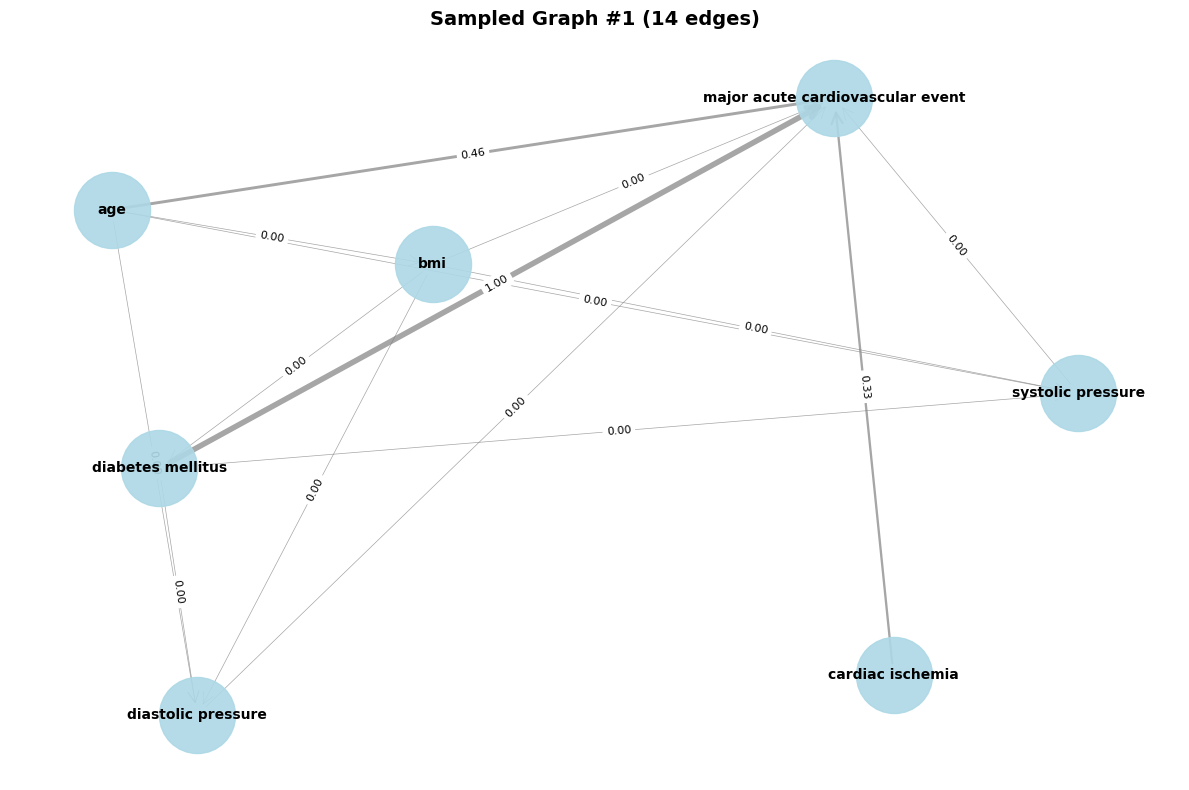

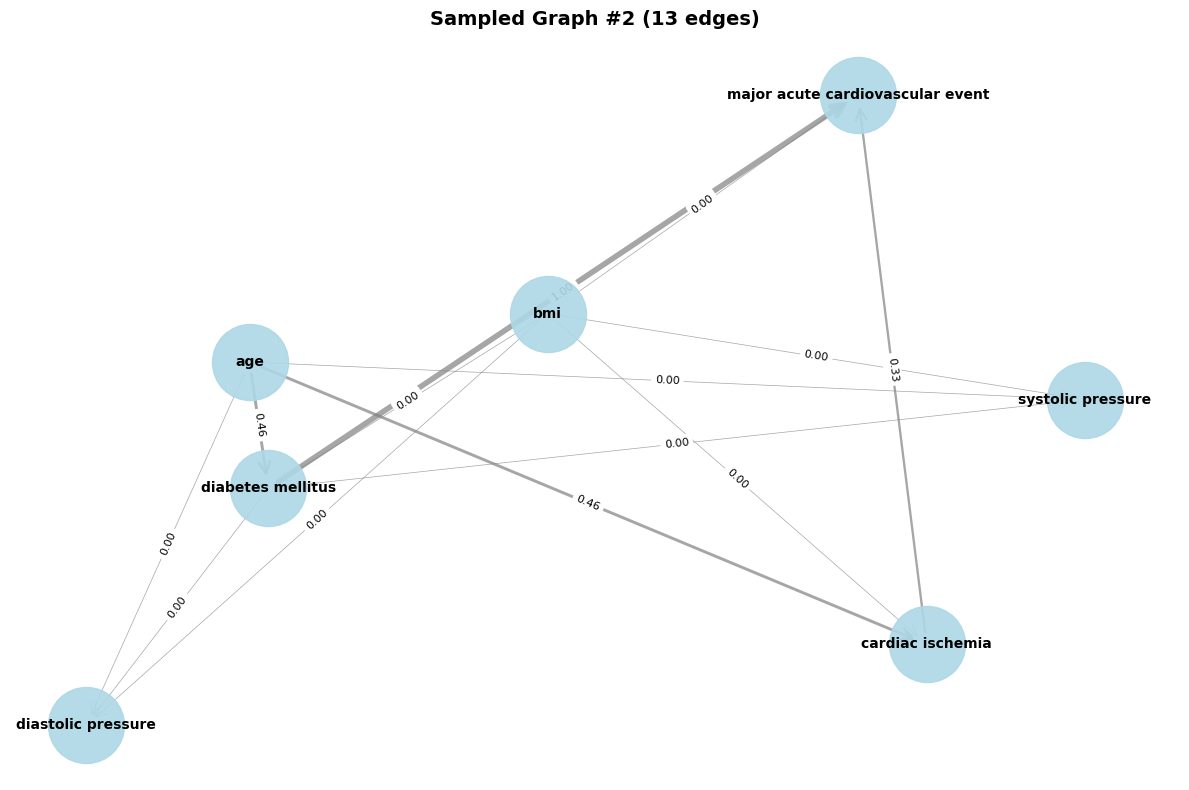

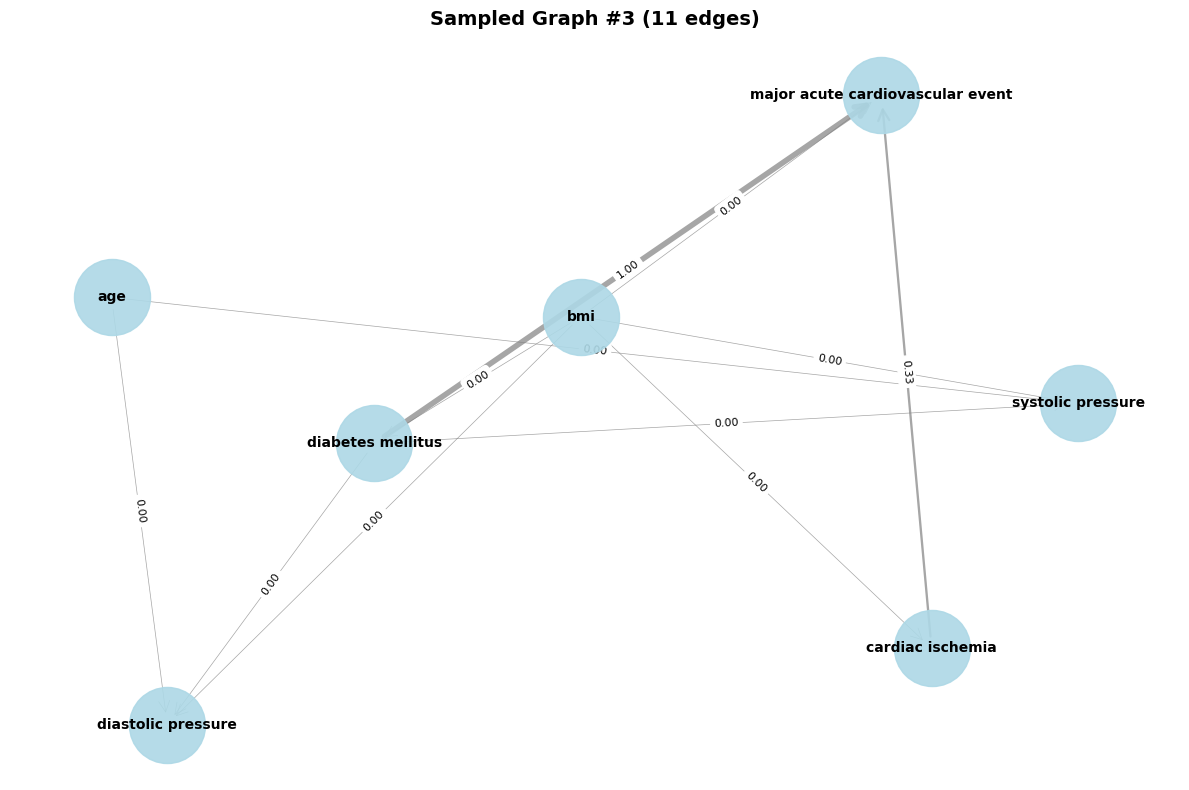

In [22]:
def visualize_sampled_graph(sampled_graph: Dict[Tuple[str, str], int], 
                           edge_probabilities: Dict[Tuple[str, str], float],
                           title: str = "Sampled Knowledge Graph",
                           figsize: Tuple[int, int] = (12, 8)):
    """
    Visualize a single sampled graph with edge probabilities as labels.
    
    Args:
        sampled_graph: Single sampled graph (dict of edges)
        edge_probabilities: Original probabilities for reference
        title: Plot title
        figsize: Figure size
    """
    G = nx.DiGraph()
    
    # Add edges that exist in this sample
    edge_labels = {}
    for (cause, effect) in sampled_graph.keys():
        G.add_edge(cause, effect)
        prob = edge_probabilities.get((cause, effect), 0.0)
        edge_labels[(cause, effect)] = f"{prob:.2f}"
    
    # Create visualization
    plt.figure(figsize=figsize)
    pos = nx.spring_layout(G, k=2, iterations=50, seed=42)
    
    # Draw nodes
    nx.draw_networkx_nodes(G, pos, node_color='lightblue', 
                          node_size=3000, alpha=0.9)
    
    # Draw edges with varying thickness based on probability
    for (cause, effect) in sampled_graph.keys():
        prob = edge_probabilities.get((cause, effect), 0.0)
        width = 0.5 + 3.5 * prob  # Width from 0.5 to 4.0
        nx.draw_networkx_edges(G, pos, [(cause, effect)], 
                              width=width, alpha=0.7, 
                              edge_color='gray', arrows=True,
                              arrowsize=20, arrowstyle='->')
    
    # Draw labels
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')
    nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=8)
    
    plt.title(title, fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Visualize first 3 sampled graphs
for i in range(min(3, len(sampled_graphs))):
    visualize_sampled_graph(
        sampled_graphs[i], 
        edge_probabilities_from_runs,
        title=f"Sampled Graph #{i+1} ({len(sampled_graphs[i])} edges)"
    )

In [24]:
graphs_json = []

for idx, graph_data in enumerate(ordered_graphs):
    adj_matrix = graph_data['adjacency_matrix']
    
    graphs_json.append({
        'graph_id': idx,
        'variables': adj_matrix.columns.tolist(),
        'adjacency_matrix': adj_matrix.values.tolist()
    })

# Save to JSON
output_path = "new_ordered_graphs.json"
with open(output_path, 'w', encoding='utf-8') as f:
    json.dump(graphs_json, f, indent=2, ensure_ascii=False)

print(f"✓ Saved {len(ordered_graphs)} graphs to {output_path}")

✓ Saved 1000 graphs to new_ordered_graphs.json


In [25]:
with open("new_ordered_graphs.json", 'r', encoding='utf-8') as f:
    loaded_graphs = json.load(f)

# Reconstruct as pandas DataFrames if needed

reconstructed_graphs = []
for graph_data in loaded_graphs:
    variables = graph_data['variables']
    matrix = graph_data['adjacency_matrix']
    
    df = pd.DataFrame(matrix, index=variables, columns=variables)
    reconstructed_graphs.append({
        'graph_id': graph_data['graph_id'],
        'adjacency_matrix': df
    })

print(f"Loaded {len(reconstructed_graphs)} graphs")

Loaded 1000 graphs


In [26]:
reconstructed_graphs[0]['adjacency_matrix']

,age,bmi,cardiac ischemia,diabetes mellitus,diastolic pressure,systolic pressure,major acute cardiovascular event
age,0,0,0,0,0,0,0
bmi,1,0,0,0,0,0,0
cardiac ischemia,0,0,0,0,0,0,0
diabetes mellitus,0,1,0,0,0,0,0
diastolic pressure,1,1,0,1,0,0,0
systolic pressure,1,1,0,1,0,0,0
major acute cardiovascular event,1,1,1,1,1,1,0


### Export Sampled Graphs

Save the sampled graphs for downstream analysis (e.g., causal inference, structural learning validation).